# Part 2a — Forecast Error Analysis

**Objective:** Understand the behavior and limitations of the wind power forecast model (WINDFOR) by examining its error characteristics.

**Dataset:**
- `actuals.csv` — Half-hourly actual wind generation (FUELHH, fuelType=WIND), January 2024
- `forecasts.csv` — Wind power forecasts (WINDFOR) with publish times, 0–48h horizon

**Questions we want to answer:**
1. What are the overall error metrics (MAE, RMSE, bias)?
2. How does the error change with forecast horizon (0.5h, 1h, 2h, ... 48h)?
3. How many predictions does the model make per day, and at what times?
4. At which hours of the day is the model most/least accurate?
5. In what conditions does the model struggle most (high wind? low wind?)?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

## 1. Load & Inspect the Data

In [2]:
actuals = pd.read_csv('actuals.csv', parse_dates=['startTime'])
forecasts = pd.read_csv('forecasts.csv', parse_dates=['startTime', 'publishTime'])

print(f'Actuals:   {len(actuals)} rows')
print(f'Forecasts: {len(forecasts)} rows')
print()
actuals.head()

Actuals:   1489 rows
Forecasts: 9582 rows



,dataset,publishTime,startTime,settlementDate,settlementPeriod,fuelType,generation
0,FUELHH,2024-02-01T00:00:00Z,2024-01-31 23:30:00+00:00,2024-01-31,48,WIND,14355
1,FUELHH,2024-01-31T23:30:00Z,2024-01-31 23:00:00+00:00,2024-01-31,47,WIND,14595
2,FUELHH,2024-01-31T23:00:00Z,2024-01-31 22:30:00+00:00,2024-01-31,46,WIND,14908
3,FUELHH,2024-01-31T22:30:00Z,2024-01-31 22:00:00+00:00,2024-01-31,45,WIND,15490
4,FUELHH,2024-01-31T22:00:00Z,2024-01-31 21:30:00+00:00,2024-01-31,44,WIND,15719


In [3]:
forecasts.head()

,dataset,publishTime,startTime,generation,horizon_hours
0,WINDFOR,2024-01-31 22:30:00+00:00,2024-01-31 23:00:00+00:00,16909,0.5
1,WINDFOR,2024-01-31 18:30:00+00:00,2024-01-31 21:00:00+00:00,17912,2.5
2,WINDFOR,2024-01-31 18:30:00+00:00,2024-01-31 22:00:00+00:00,17670,3.5
3,WINDFOR,2024-01-31 18:30:00+00:00,2024-01-31 23:00:00+00:00,17275,4.5
4,WINDFOR,2024-01-31 15:30:00+00:00,2024-01-31 21:00:00+00:00,17887,5.5


In [4]:
print('--- Actuals ---')
print(actuals['generation'].describe())
print()
print('--- Forecasts ---')
print(forecasts['generation'].describe())
print()
print('--- Horizon ---')
print(forecasts['horizon_hours'].describe())

--- Actuals ---
count     1489.000000
mean      9848.818670
std       3674.784894
min          0.000000
25%       6733.000000
50%       9883.000000
75%      13105.000000
max      16662.000000
Name: generation, dtype: float64

--- Forecasts ---
count     9582.000000
mean     11127.477980
std       4820.816713
min       2708.000000
25%       6872.500000
50%      10095.500000
75%      15769.750000
max      19818.000000
Name: generation, dtype: float64

--- Horizon ---
count    9582.000000
mean       28.081507
std        11.952671
min         0.500000
25%        18.500000
50%        28.500000
75%        38.500000
max        48.000000
Name: horizon_hours, dtype: float64


## 2. Observe the Actuals

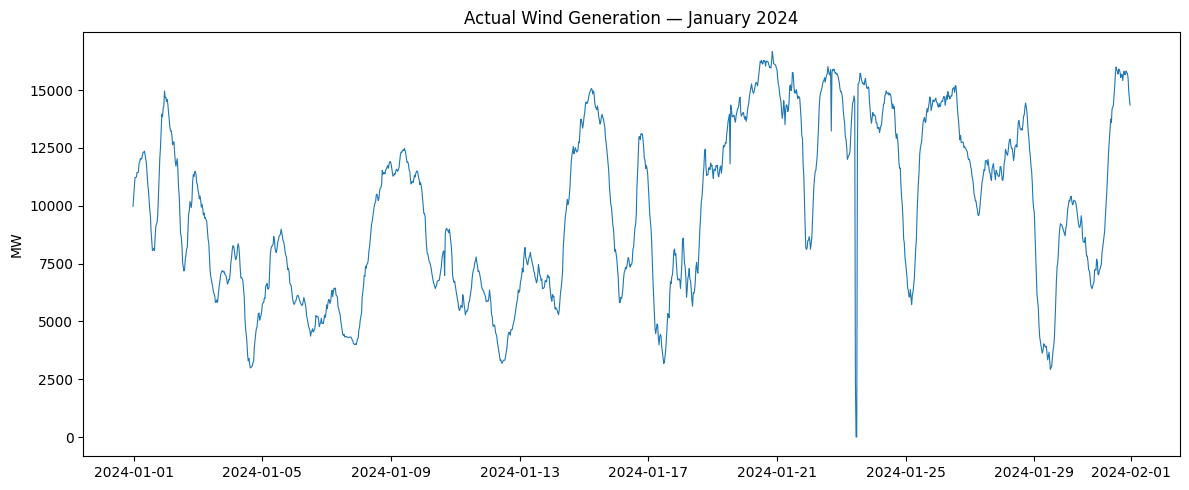

In [5]:
actuals_sorted = actuals.sort_values('startTime')

plt.plot(actuals_sorted['startTime'], actuals_sorted['generation'], linewidth=0.8)
plt.ylabel('MW')
plt.title('Actual Wind Generation — January 2024')
plt.tight_layout()
plt.show()

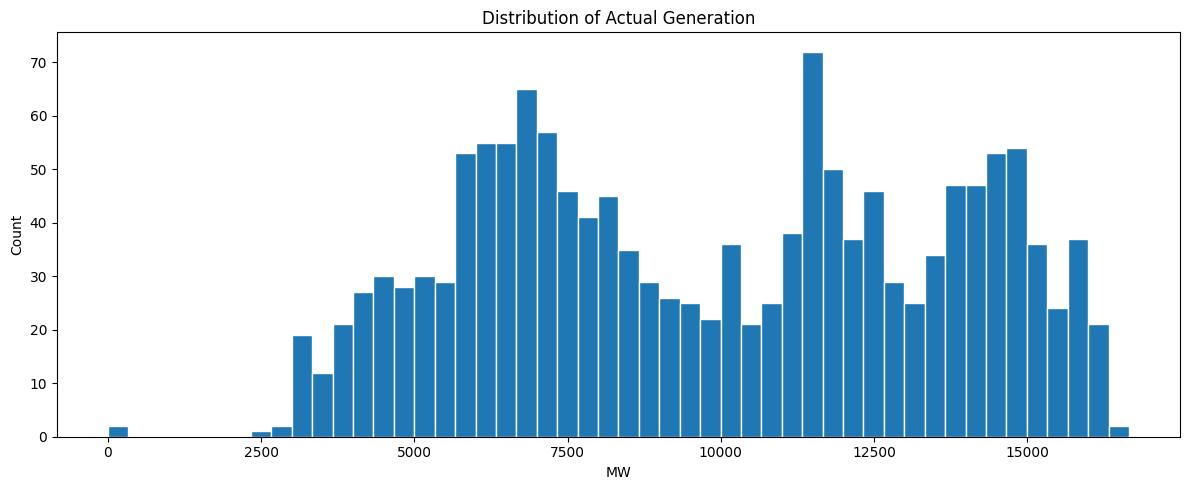

In [6]:
plt.hist(actuals['generation'], bins=50, edgecolor='white')
plt.xlabel('MW')
plt.ylabel('Count')
plt.title('Distribution of Actual Generation')
plt.tight_layout()
plt.show()

## 3. Observe the Forecasts

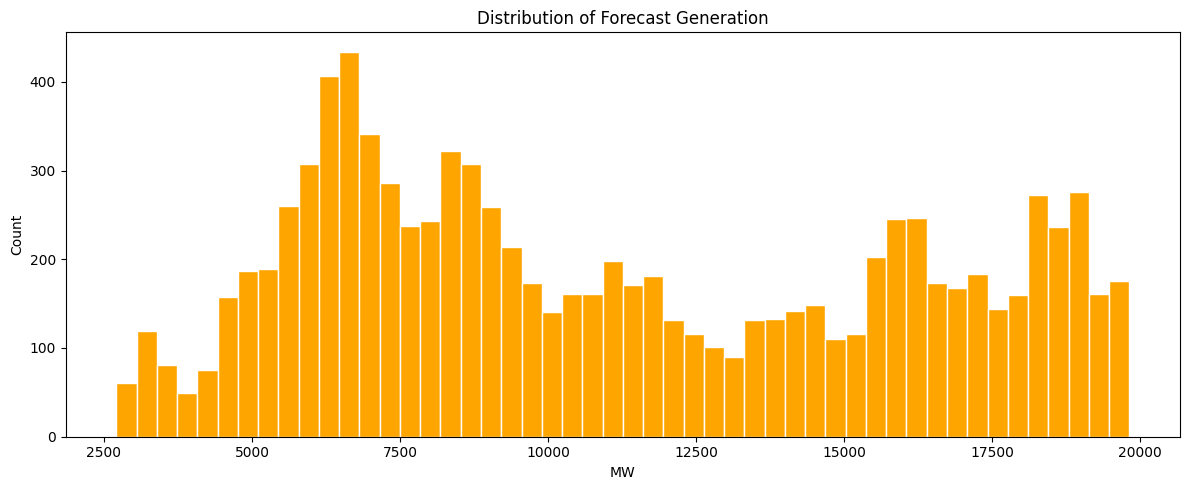

In [7]:
plt.hist(forecasts['generation'], bins=50, edgecolor='white', color='orange')
plt.xlabel('MW')
plt.ylabel('Count')
plt.title('Distribution of Forecast Generation')
plt.tight_layout()
plt.show()

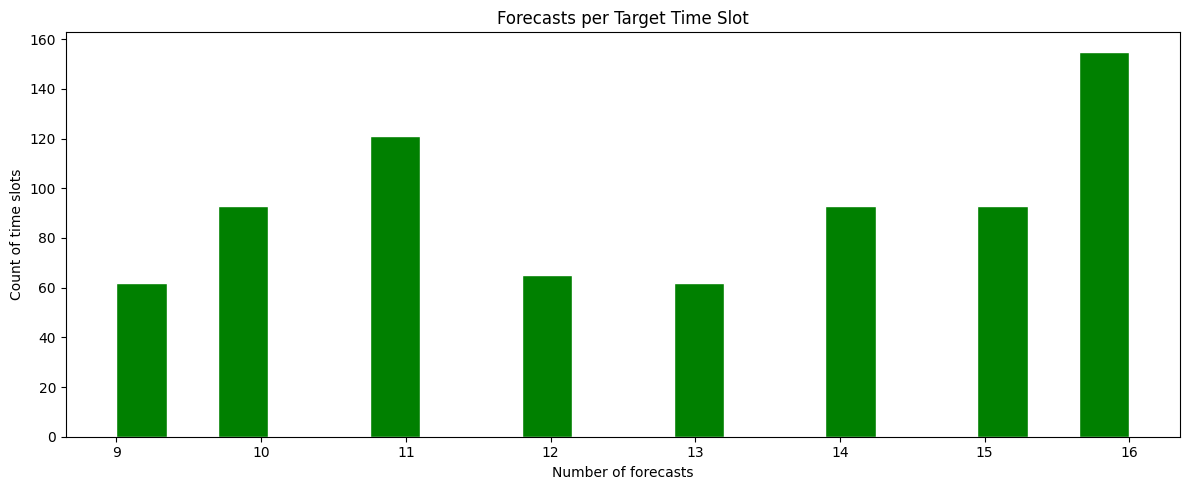

In [8]:
# How many forecasts per time slot?
forecasts_per_slot = forecasts.groupby('startTime').size()

plt.hist(forecasts_per_slot, bins=20, edgecolor='white', color='green')
plt.xlabel('Number of forecasts')
plt.ylabel('Count of time slots')
plt.title('Forecasts per Target Time Slot')
plt.tight_layout()
plt.show()

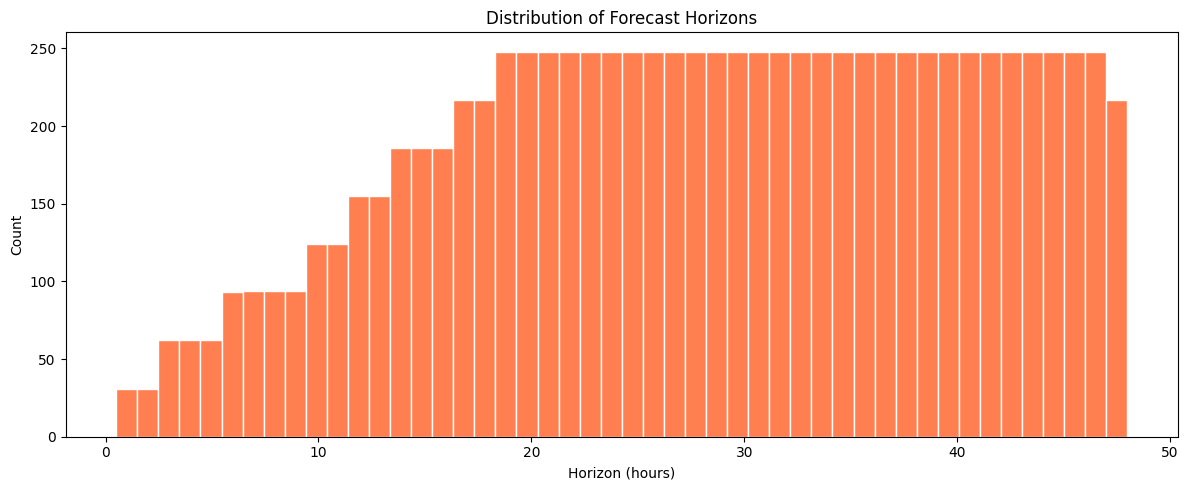

In [9]:
plt.hist(forecasts['horizon_hours'], bins=48, edgecolor='white', color='coral')
plt.xlabel('Horizon (hours)')
plt.ylabel('Count')
plt.title('Distribution of Forecast Horizons')
plt.tight_layout()
plt.show()

## 4. Overlay: Forecasts vs Actuals

Quick visual — pick 4h horizon and plot against actuals.

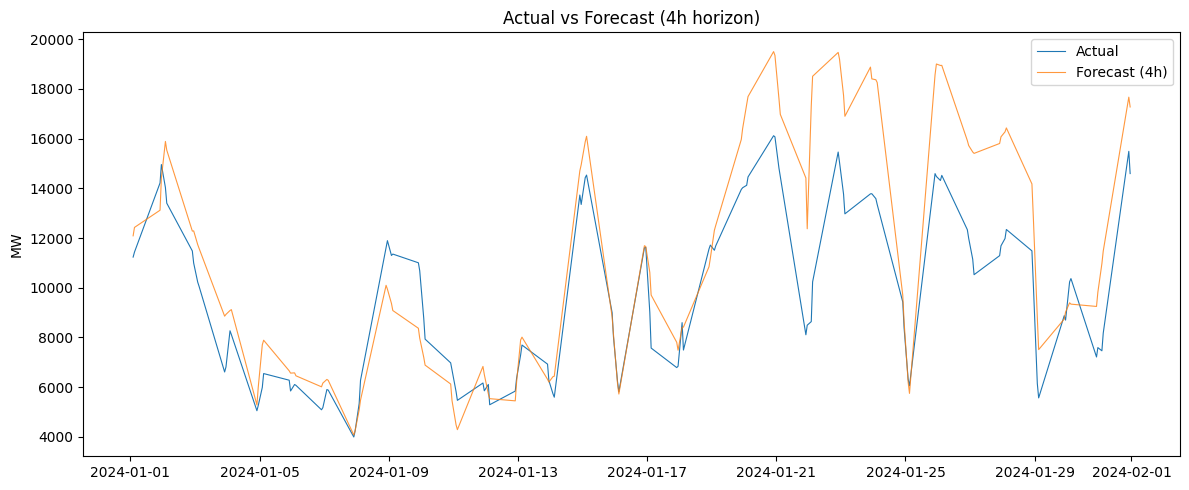

In [10]:
f4 = forecasts[(forecasts['horizon_hours'] >= 3.5) & (forecasts['horizon_hours'] <= 4.5)]
f4_best = f4.sort_values('horizon_hours').groupby('startTime').first().reset_index()

merged = f4_best.merge(actuals_sorted[['startTime', 'generation']], on='startTime', suffixes=('_forecast', '_actual'))
merged = merged.sort_values('startTime')

plt.plot(merged['startTime'], merged['generation_actual'], linewidth=0.8, label='Actual')
plt.plot(merged['startTime'], merged['generation_forecast'], linewidth=0.8, label='Forecast (4h)', alpha=0.8)
plt.ylabel('MW')
plt.title('Actual vs Forecast (4h horizon)')
plt.legend()
plt.tight_layout()
plt.show()

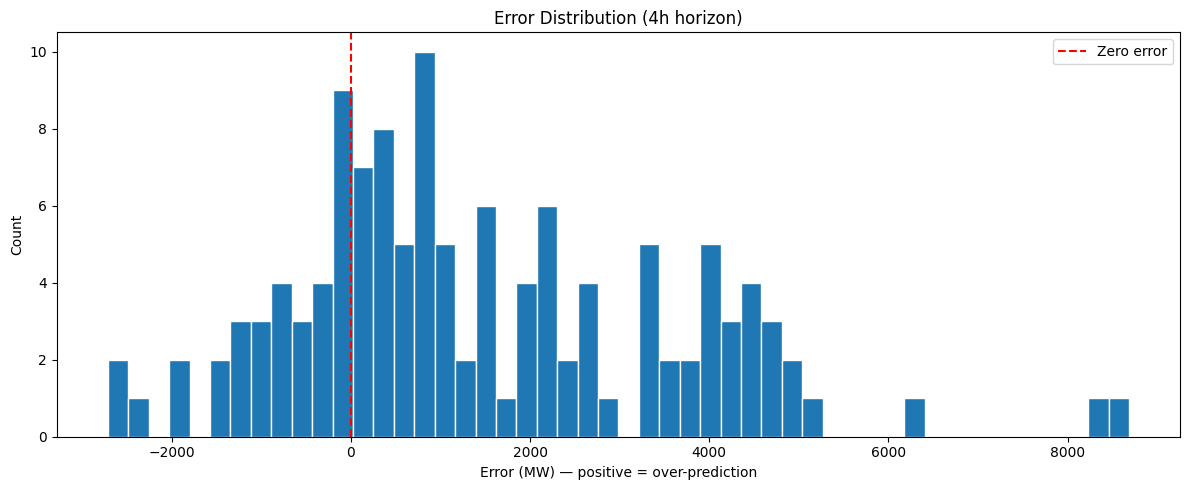

Mean error (bias): +1,440 MW
Over-predictions:  74%


In [11]:
merged['error'] = merged['generation_forecast'] - merged['generation_actual']

plt.hist(merged['error'], bins=50, edgecolor='white')
plt.axvline(0, color='red', linestyle='--', label='Zero error')
plt.xlabel('Error (MW) — positive = over-prediction')
plt.ylabel('Count')
plt.title('Error Distribution (4h horizon)')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Mean error (bias): {merged["error"].mean():+,.0f} MW')
print(f'Over-predictions:  {(merged["error"] > 0).mean()*100:.0f}%')

---

## 5. Merge All Forecasts with Actuals

Now let's merge the full forecast dataset with actuals so we can compute errors across all horizons.

In [12]:
# Clean: remove any zero-generation actuals (data artifacts)
actuals_clean = actuals[actuals['generation'] > 0][['startTime', 'generation']].copy()
actuals_clean.rename(columns={'generation': 'actual_mw'}, inplace=True)

forecasts_clean = forecasts[['startTime', 'publishTime', 'generation', 'horizon_hours']].copy()
forecasts_clean.rename(columns={'generation': 'forecast_mw'}, inplace=True)

# Merge
df = forecasts_clean.merge(actuals_clean, on='startTime', how='inner')
df['error'] = df['forecast_mw'] - df['actual_mw']      # positive = over-prediction
df['abs_error'] = df['error'].abs()

print(f'Merged dataset: {len(df):,} forecast-actual pairs')
print(f'Unique target slots: {df["startTime"].nunique()}')

Merged dataset: 9,570 forecast-actual pairs
Unique target slots: 743


---

## 6. Question 1 — Overall Error Metrics

How good (or bad) is the model overall?

In [13]:
mae = df['abs_error'].mean()
rmse = np.sqrt((df['error'] ** 2).mean())
mse = (df['error'] ** 2).mean()
bias = df['error'].mean()
median_ae = df['abs_error'].median()
p99 = df['abs_error'].quantile(0.99)

print('Overall Error Metrics:')
print(f'  Mean Absolute Error (MAE):  {mae:>8,.0f} MW')
print(f'  Median Absolute Error:      {median_ae:>8,.0f} MW')
print(f'  Root Mean Square Error:     {rmse:>8,.0f} MW')
print(f'  Mean Squared Error:         {mse:>12,.0f} MW²')
print(f'  Mean Error (Bias):          {bias:>+8,.0f} MW')
print(f'  P99 Absolute Error:         {p99:>8,.0f} MW')
print()
print(f'  Over-predictions: {(df["error"] > 0).mean()*100:.1f}%')
print(f'  Under-predictions: {(df["error"] < 0).mean()*100:.1f}%')

Overall Error Metrics:
  Mean Absolute Error (MAE):     2,049 MW
  Median Absolute Error:         1,775 MW
  Root Mean Square Error:        2,597 MW
  Mean Squared Error:            6,742,665 MW²
  Mean Error (Bias):            +1,298 MW
  P99 Absolute Error:            7,332 MW

  Over-predictions: 72.6%
  Under-predictions: 27.4%


---

## 7. Question 2a — Error vs Forecast Horizon

How does accuracy change as we predict further into the future? We bucket horizons into 2-hour bands.

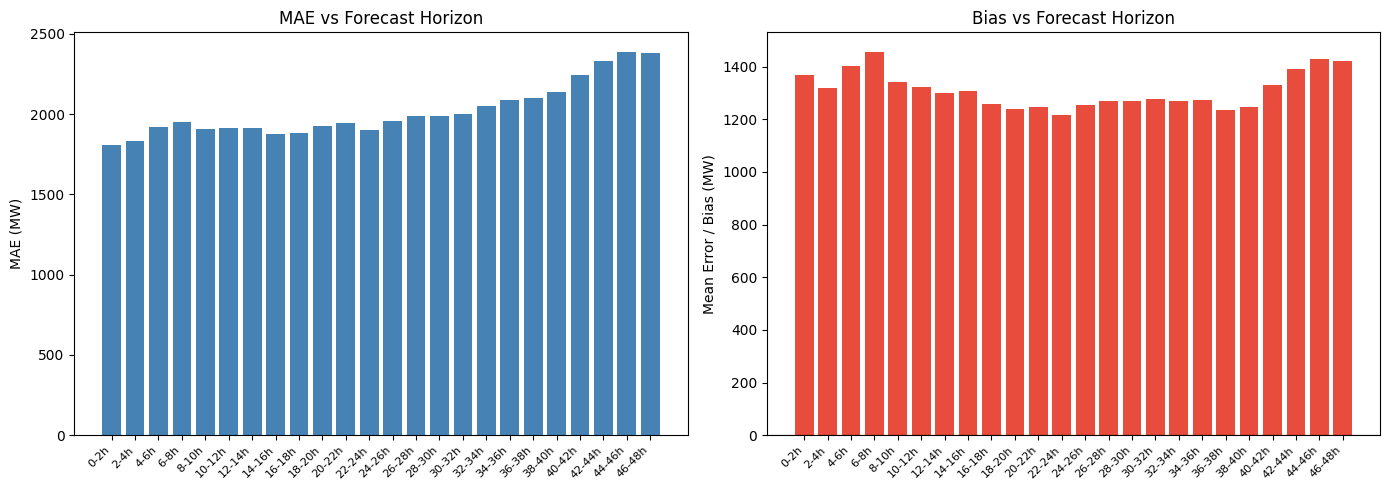

horizon_band         mae        bias  count
        0-2h 1808.532258 1369.790323     62
        2-4h 1835.298387 1320.395161    124
        4-6h 1919.419355 1402.296774    155
        6-8h 1952.691489 1457.531915    188
       8-10h 1906.788991 1342.119266    218
      10-12h 1913.157706 1323.473118    279
      12-14h 1912.914706 1299.538235    340
      14-16h 1876.836022 1306.051075    372
      16-18h 1882.466513 1259.792148    433
      18-20h 1923.531313 1239.818182    495
      20-22h 1943.338710 1246.540323    496
      22-24h 1902.571717 1214.943434    495
      24-26h 1959.002020 1253.753535    495
      26-28h 1989.111111 1268.925253    495
      28-30h 1987.169355 1268.193548    496
      30-32h 1999.438384 1275.753535    495
      32-34h 2051.092929 1270.709091    495
      34-36h 2088.655242 1273.941532    496
      36-38h 2099.036364 1234.256566    495
      38-40h 2139.042339 1246.058468    496
      40-42h 2245.820202 1330.882828    495
      42-44h 2332.789899 1392.87

In [14]:
# Bucket into 2-hour horizon bands
bins = list(range(0, 50, 2))
labels = [f'{b}-{b+2}h' for b in bins[:-1]]
df['horizon_band'] = pd.cut(df['horizon_hours'], bins=bins, labels=labels, right=True)

horizon_stats = df.groupby('horizon_band', observed=True).agg(
    mae=('abs_error', 'mean'),
    bias=('error', 'mean'),
    count=('error', 'size')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAE vs horizon
axes[0].bar(range(len(horizon_stats)), horizon_stats['mae'], color='steelblue')
axes[0].set_xticks(range(len(horizon_stats)))
axes[0].set_xticklabels(horizon_stats['horizon_band'], rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('MAE (MW)')
axes[0].set_title('MAE vs Forecast Horizon')

# Bias vs horizon
colors = ['#e74c3c' if b > 0 else '#3498db' for b in horizon_stats['bias']]
axes[1].bar(range(len(horizon_stats)), horizon_stats['bias'], color=colors)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xticks(range(len(horizon_stats)))
axes[1].set_xticklabels(horizon_stats['horizon_band'], rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Mean Error / Bias (MW)')
axes[1].set_title('Bias vs Forecast Horizon')

plt.tight_layout()
plt.show()

print(horizon_stats.to_string(index=False))

---

## 7b. Question 2b — How Often Does the Model Predict & At What Times?

Let's understand the model's publish schedule — when does it issue forecasts?

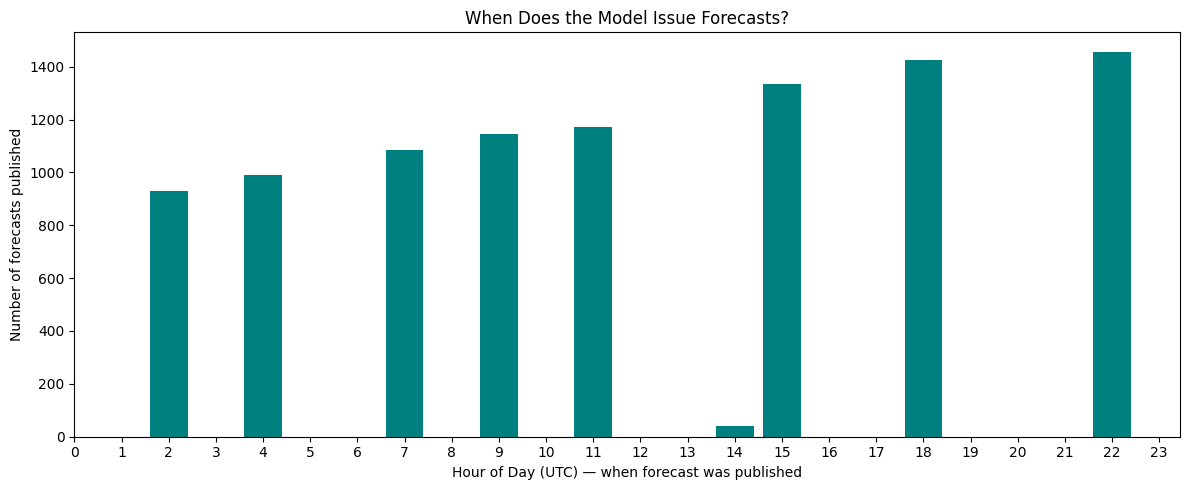

Model runs per day: mean=8, min=8, max=8


In [15]:
# When does the model publish forecasts (by hour of day)?
forecasts['publish_hour'] = forecasts['publishTime'].dt.hour

publish_counts = forecasts.groupby('publish_hour').size()

plt.bar(publish_counts.index, publish_counts.values, color='teal')
plt.xlabel('Hour of Day (UTC) — when forecast was published')
plt.ylabel('Number of forecasts published')
plt.title('When Does the Model Issue Forecasts?')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

# How many unique publish times per day?
forecasts['publish_date'] = forecasts['publishTime'].dt.date
runs_per_day = forecasts.groupby('publish_date')['publishTime'].nunique()
print(f'Model runs per day: mean={runs_per_day.mean():.0f}, min={runs_per_day.min()}, max={runs_per_day.max()}')

---

## 7c. Question 2c — Error by Hour of Day

For which hours of the day is the model most/least accurate?

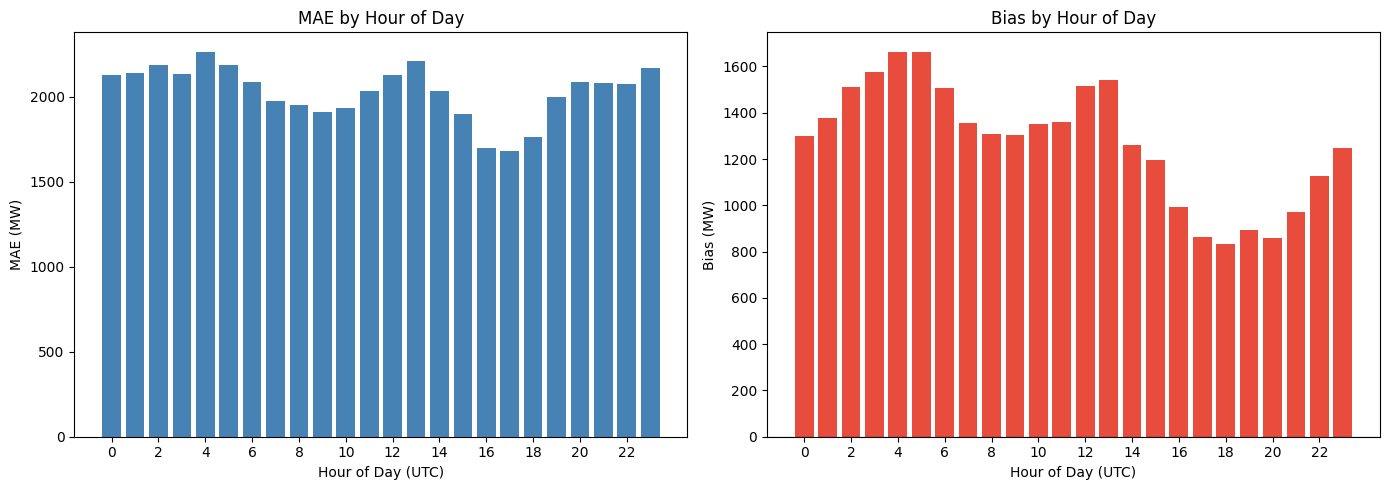

Best hour:  17:00 — MAE 1,684 MW
Worst hour: 04:00 — MAE 2,267 MW


In [16]:
df['hour'] = df['startTime'].dt.hour

hourly_stats = df.groupby('hour').agg(
    mae=('abs_error', 'mean'),
    bias=('error', 'mean'),
    count=('error', 'size')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(hourly_stats['hour'], hourly_stats['mae'], color='steelblue')
axes[0].set_xlabel('Hour of Day (UTC)')
axes[0].set_ylabel('MAE (MW)')
axes[0].set_title('MAE by Hour of Day')
axes[0].set_xticks(range(0, 24, 2))

colors = ['#e74c3c' if b > 0 else '#3498db' for b in hourly_stats['bias']]
axes[1].bar(hourly_stats['hour'], hourly_stats['bias'], color=colors)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Hour of Day (UTC)')
axes[1].set_ylabel('Bias (MW)')
axes[1].set_title('Bias by Hour of Day')
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

best = hourly_stats.loc[hourly_stats['mae'].idxmin()]
worst = hourly_stats.loc[hourly_stats['mae'].idxmax()]
print(f'Best hour:  {int(best["hour"]):02d}:00 — MAE {best["mae"]:,.0f} MW')
print(f'Worst hour: {int(worst["hour"]):02d}:00 — MAE {worst["mae"]:,.0f} MW')

---

## 8. Question 3 — When Does the Model Struggle Most?

Is the error worse when actual wind is high or low? Let's plot error against actual generation level.

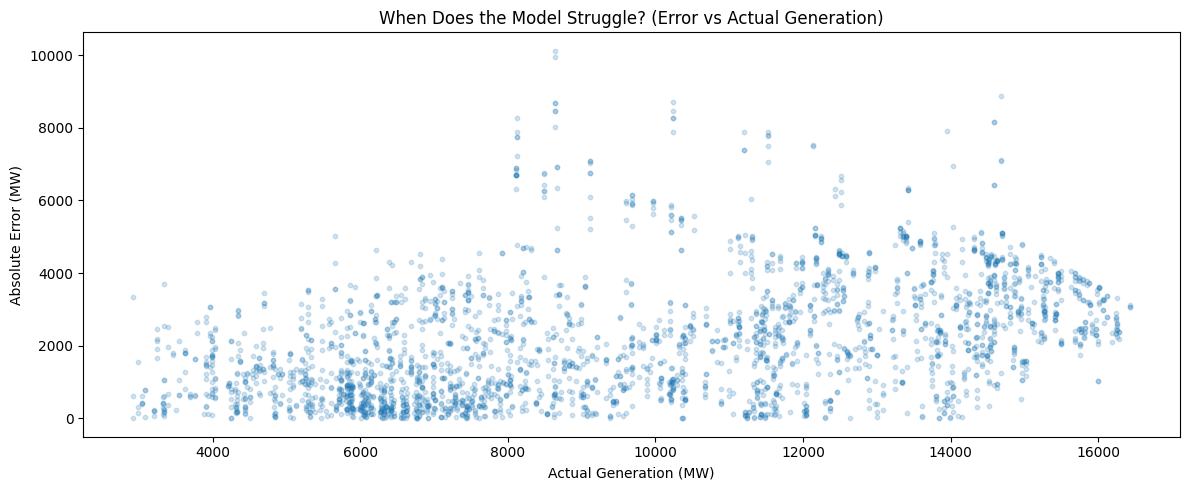

In [17]:
# Scatter: actual generation vs absolute error
# Use a sample to avoid overplotting
sample = df.sample(min(3000, len(df)), random_state=42)

plt.scatter(sample['actual_mw'], sample['abs_error'], alpha=0.2, s=10)
plt.xlabel('Actual Generation (MW)')
plt.ylabel('Absolute Error (MW)')
plt.title('When Does the Model Struggle? (Error vs Actual Generation)')
plt.tight_layout()
plt.show()

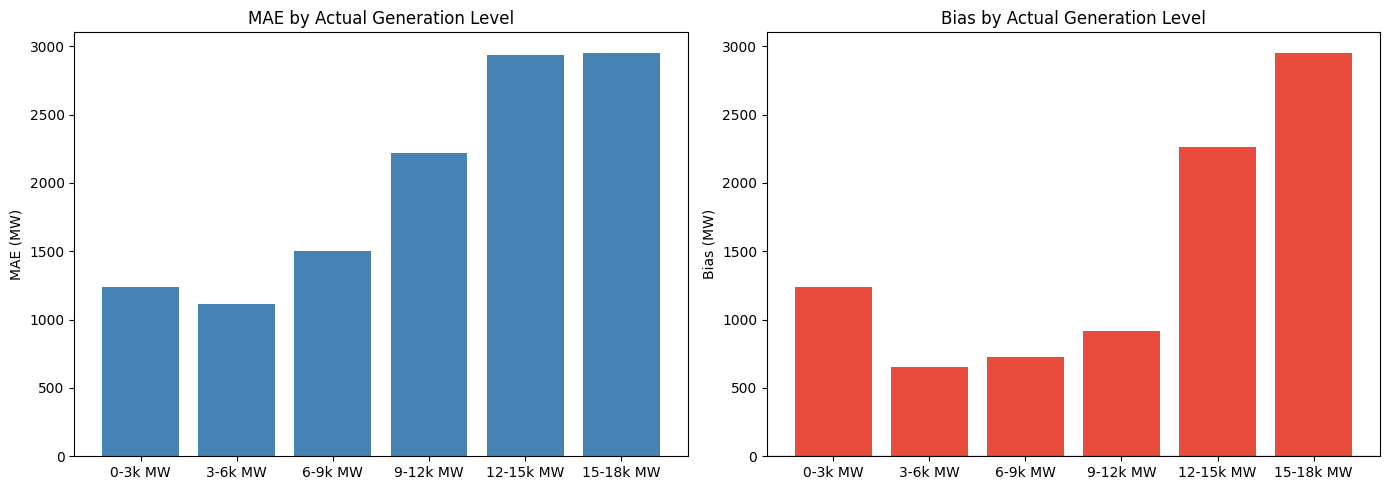

actual_band         mae        bias  count
    0-3k MW 1239.818182 1239.818182     22
    3-6k MW 1110.538125  655.944375   1600
    6-9k MW 1498.988269  723.913971   2813
   9-12k MW 2215.906416  915.206946   2073
  12-15k MW 2934.107490 2264.051629   2363
  15-18k MW 2953.962804 2953.962804    699


In [18]:
# Bucket actuals into ranges and compute MAE for each
actual_bins = [0, 3000, 6000, 9000, 12000, 15000, 18000]
actual_labels = [f'{actual_bins[i]//1000}-{actual_bins[i+1]//1000}k MW' for i in range(len(actual_bins)-1)]
df['actual_band'] = pd.cut(df['actual_mw'], bins=actual_bins, labels=actual_labels, right=True)

struggle_stats = df.groupby('actual_band', observed=True).agg(
    mae=('abs_error', 'mean'),
    bias=('error', 'mean'),
    count=('error', 'size')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(len(struggle_stats)), struggle_stats['mae'], color='steelblue')
axes[0].set_xticks(range(len(struggle_stats)))
axes[0].set_xticklabels(struggle_stats['actual_band'])
axes[0].set_ylabel('MAE (MW)')
axes[0].set_title('MAE by Actual Generation Level')

colors = ['#e74c3c' if b > 0 else '#3498db' for b in struggle_stats['bias']]
axes[1].bar(range(len(struggle_stats)), struggle_stats['bias'], color=colors)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xticks(range(len(struggle_stats)))
axes[1].set_xticklabels(struggle_stats['actual_band'])
axes[1].set_ylabel('Bias (MW)')
axes[1].set_title('Bias by Actual Generation Level')

plt.tight_layout()
plt.show()

print(struggle_stats.to_string(index=False))

---

## 9. Error by Publish Hour — When the Forecast Is Issued

Different from the target-hour analysis above: here we ask — does it matter *when the model runs* (publishes its forecast)? Forecasts issued at different times of day may have different accuracy.

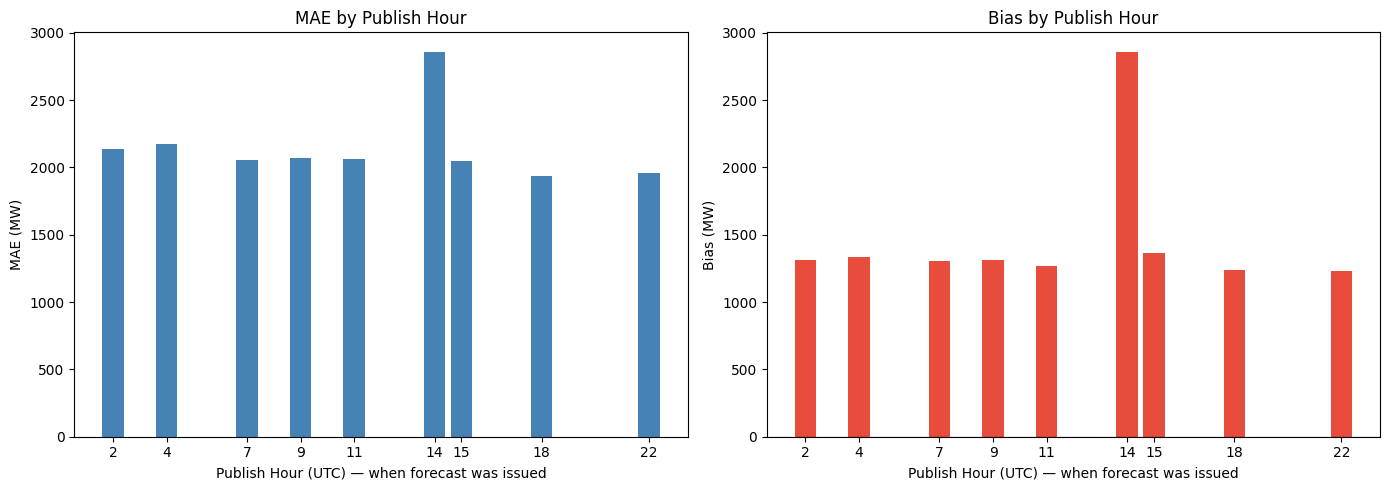

 publish_hour         mae        bias  count
            2 2137.979548 1315.497309    929
            4 2170.002018 1337.905146    991
            7 2058.194649 1303.109779   1084
            9 2071.545375 1310.571553   1146
           11 2065.229452 1265.044521   1168
           14 2859.880952 2859.880952     42
           15 2050.507889 1362.378663   1331
           18 1934.345506 1239.147472   1424
           22 1962.003436 1228.281100   1455

Most accurate publish hour:  18:00 — MAE 1,934 MW (1,424 forecasts)
Least accurate publish hour: 14:00 — MAE 2,860 MW (42 forecasts)


In [19]:
df['publish_hour'] = df['publishTime'].dt.hour

publish_stats = df.groupby('publish_hour').agg(
    mae=('abs_error', 'mean'),
    bias=('error', 'mean'),
    count=('error', 'size')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(publish_stats['publish_hour'], publish_stats['mae'], color='steelblue')
axes[0].set_xlabel('Publish Hour (UTC) — when forecast was issued')
axes[0].set_ylabel('MAE (MW)')
axes[0].set_title('MAE by Publish Hour')
axes[0].set_xticks(publish_stats['publish_hour'])

colors = ['#e74c3c' if b > 0 else '#3498db' for b in publish_stats['bias']]
axes[1].bar(publish_stats['publish_hour'], publish_stats['bias'], color=colors)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Publish Hour (UTC) — when forecast was issued')
axes[1].set_ylabel('Bias (MW)')
axes[1].set_title('Bias by Publish Hour')
axes[1].set_xticks(publish_stats['publish_hour'])

plt.tight_layout()
plt.show()

print(publish_stats.to_string(index=False))
print()
best_ph = publish_stats.loc[publish_stats['mae'].idxmin()]
worst_ph = publish_stats.loc[publish_stats['mae'].idxmax()]
print(f'Most accurate publish hour:  {int(best_ph["publish_hour"]):02d}:00 — MAE {best_ph["mae"]:,.0f} MW ({int(best_ph["count"]):,} forecasts)')
print(f'Least accurate publish hour: {int(worst_ph["publish_hour"]):02d}:00 — MAE {worst_ph["mae"]:,.0f} MW ({int(worst_ph["count"]):,} forecasts)')

---

## 10. Observations

**Observation 1 — The model has a systematic over-prediction bias.**  
72.6% of all forecast-actual pairs are over-predictions, with an average bias of +1,298 MW. This is concerning from a grid-operations perspective: over-prediction means the grid plans for generation that doesn't materialise, which can lead to scarcity and the need for expensive last-minute balancing. Under-prediction (actual > forecast) is the safer direction, since surplus generation is easier to manage than a shortfall.

**Observation 2 — MAE increases with forecast horizon; bias stays roughly constant.**  
MAE grows from ~1,809 MW at the 0–2h horizon to ~2,380 MW at 46–48h — a ~30% degradation over the full 48-hour window. However, the increase is gradual and the base error is already large, so the horizon effect is relatively modest (correlation r ≈ 0.09). Bias, on the other hand, stays in the +1,200–1,450 MW band across all horizons with no clear upward or downward trend — the model's systematic over-prediction does not worsen (or improve) with time.

**Observation 3 — Forecast accuracy varies by time of day (target hour).**  
The model is most accurate for the 16:00–17:00 hours (MAE ~1,700 MW) and least accurate for 04:00–05:00 and 13:00 (MAE ~2,200+ MW). The bias is highest in the early morning (04:00–05:00, bias ~1,660 MW) and lowest in the evening (17:00–18:00, bias ~860 MW). This ~500 MW spread in MAE across hours suggests the model's skill is not uniform throughout the day.

**Observation 4 — Higher actual generation leads to higher absolute error, but relative error is stable.**  
MAE increases from ~1,111 MW (3–6k actual band) to ~2,954 MW (15–18k band). However, when expressed as a percentage of actual generation, the error is fairly stable at ~19–22% across most bands. The exception is the very low generation band (0–3k MW) where relative error spikes to 42%, though this has very few data points (22 pairs). The model's proportional accuracy is roughly consistent — larger numbers simply produce larger absolute errors.

**Observation 5 — Forecasts issued in the evening are more accurate than those issued early morning.**  
The model publishes forecasts at approximately 8 distinct hours per day (02, 04, 07, 09, 11, 15, 18, 22 UTC). Forecasts issued at 18:00 and 22:00 are the most accurate (MAE ~1,934 and ~1,962 MW), while those issued at 04:00 are the worst among the main publish hours (MAE ~2,170 MW). This likely reflects that evening forecasts cover shorter effective horizons for the next several hours, and weather conditions may be more settled by evening. This is a distinct insight from Observation 3 — Obs 3 asks 'for which target hour is the forecast accurate?' while Obs 5 asks 'when the model *runs*, which run produces better forecasts?'